# EDA - ReActiva

Exploración del dataset de compras para entender el comportamiento de los clientes, los productos y los principales patrones que pueden ser útiles para el sistema de recomendación.

La idea de este análisis es revisar cómo se distribuyen las compras en el tiempo, qué diferencias aparecen entre clientes, productos, canales y ubicaciones, y detectar patrones que después puedan servir para definir features y evaluar el recomendador.

### Carga de librerias e importaciones

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from reactiva.data.load_data import cargar_datos

from matplotlib.patches import Patch

from scipy.stats import chi2_contingency


### Carga y recuento del dataset

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
df = cargar_datos()
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 10,000
Columnas: 27


## 1. Panorama general de compras y clientes

Antes de analizar patrones más específicos, revisamos el tamaño de la actividad comercial y cómo se distribuyen las compras entre los clientes.

Este bloque busca responder cuántas transacciones existen, cuántos clientes distintos participan y con qué frecuencia aparecen en el histórico.

In [3]:
# Cantidad total de transacciones registradas en el dataset
total_transacciones = len(df)
# Cantidad de clientes distintos presentes en el histórico
clientes_unicos = df["Customer ID"].nunique()
# Cantidad de compras realizadas por cada cliente
compras_por_cliente = (
    df.groupby("Customer ID")
      .size()
      .sort_values(ascending=False)
)

# Resumen general de la actividad de los clientes
print(f"Transacciones totales: {total_transacciones:,}")
print(f"Clientes únicos: {clientes_unicos:,}")
print(f"Promedio de compras por cliente: {compras_por_cliente.mean():.2f}")
print(f"Mediana de compras por cliente: {compras_por_cliente.median():.0f}")
print(f"Mínimo de compras por cliente: {compras_por_cliente.min()}")
print(f"Máximo de compras por cliente: {compras_por_cliente.max()}")

# Separación entre clientes con una única compra y clientes recurrentes
print(f"Clientes con una sola compra: {(compras_por_cliente == 1).sum():,}")
print(f"Clientes con más de una compra: {(compras_por_cliente > 1).sum():,}")

Transacciones totales: 10,000
Clientes únicos: 3,291
Promedio de compras por cliente: 3.04
Mediana de compras por cliente: 3
Mínimo de compras por cliente: 1
Máximo de compras por cliente: 10
Clientes con una sola compra: 598
Clientes con más de una compra: 2,693


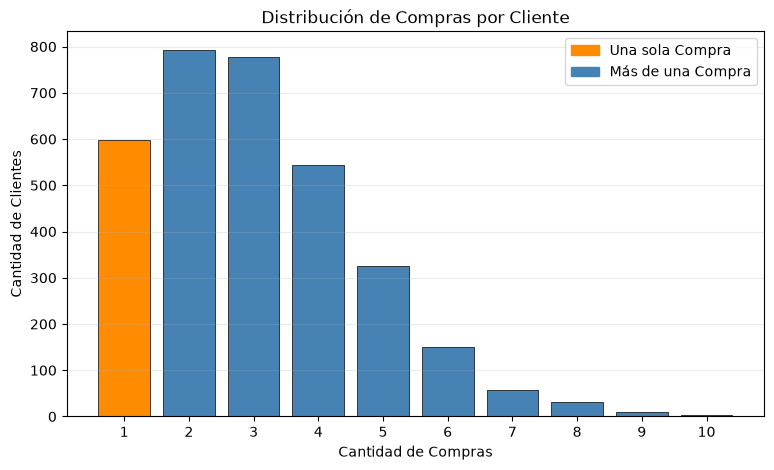

In [4]:
# Frecuencia de clientes según la cantidad de compras realizadas
distribucion_compras = compras_por_cliente.value_counts().sort_index()
# Diferenciamos clientes de una sola compra de los clientes recurrentes
colores = [
    "darkorange" if compras == 1 else "steelblue"
    for compras in distribucion_compras.index
]
# Gráfico de la distribución de compras por cliente
plt.figure(figsize=(9, 5))
plt.bar(
    distribucion_compras.index,
    distribucion_compras.values,
    color=colores,
    edgecolor="black",
    linewidth=0.5
)
plt.title("Distribución de Compras por Cliente")
plt.xlabel("Cantidad de Compras")
plt.ylabel("Cantidad de Clientes")
plt.xticks(distribucion_compras.index)
plt.grid(axis="y", alpha=0.25)
# Referencia de colores
leyenda = [
    Patch(color="darkorange", label="Una sola Compra"),
    Patch(color="steelblue", label="Más de una Compra")
]
plt.legend(handles=leyenda)
plt.show()

El histórico contiene 3.291 clientes distintos y 10.000 transacciones. La mayor parte de los clientes aparece más de una vez en el dataset: 2.693 clientes tienen al menos dos compras registradas, mientras que 598 realizaron una sola compra. La distribución muestra que la mayor concentración se encuentra entre 2 y 4 compras por cliente y que, a medida que aumenta la cantidad de compras, la cantidad de clientes disminuye. Para ReActiva esto es importante porque existe una proporción considerable de clientes con historial suficiente como para analizar patrones de compra y construir recomendaciones a partir de comportamientos previos. Sin embargo, tener más de una transacción registrada no permite afirmar por sí solo que exista una recompra dentro de una ventana temporal determinada. Esa condición se analizará más adelante incorporando las fechas de compra.

## 2. Comportamiento temporal de las compras

En este bloque analizamos cómo se distribuyen las transacciones a lo largo del tiempo.

El objetivo es identificar el período cubierto por el dataset, observar la evolución mensual de las compras y detectar posibles cambios o concentraciones temporales que puedan ser relevantes para el sistema de recomendación.

In [5]:
# Trabajamos sobre una copia para conservar intacto el dataframe cargado originalmente
df_eda = df.copy()
# Convertimos la fecha de compra a formato datetime para poder analizarla temporalmente
df_eda["Purchase Date"] = pd.to_datetime(
    df_eda["Purchase Date"],
    errors="coerce"
)
# Fechas mínima y máxima disponibles en el histórico
fecha_inicio = df_eda["Purchase Date"].min()
fecha_fin = df_eda["Purchase Date"].max()
# Cantidad de días cubiertos por el dataset
dias_historico = (fecha_fin - fecha_inicio).days + 1
print(f"Primera compra registrada: {fecha_inicio.date()}")
print(f"Última compra registrada: {fecha_fin.date()}")
print(f"Días cubiertos por el histórico: {dias_historico:,}")
print(f"Fechas no interpretables: {df_eda['Purchase Date'].isna().sum():,}")

Primera compra registrada: 2023-01-01
Última compra registrada: 2024-12-30
Días cubiertos por el histórico: 730
Fechas no interpretables: 0


,Cantidad de compras
Purchase Date,
2023-01-01,428
2023-02-01,383
2023-03-01,418
2023-04-01,414
2023-05-01,474
2023-06-01,403
2023-07-01,403
2023-08-01,435
2023-09-01,399


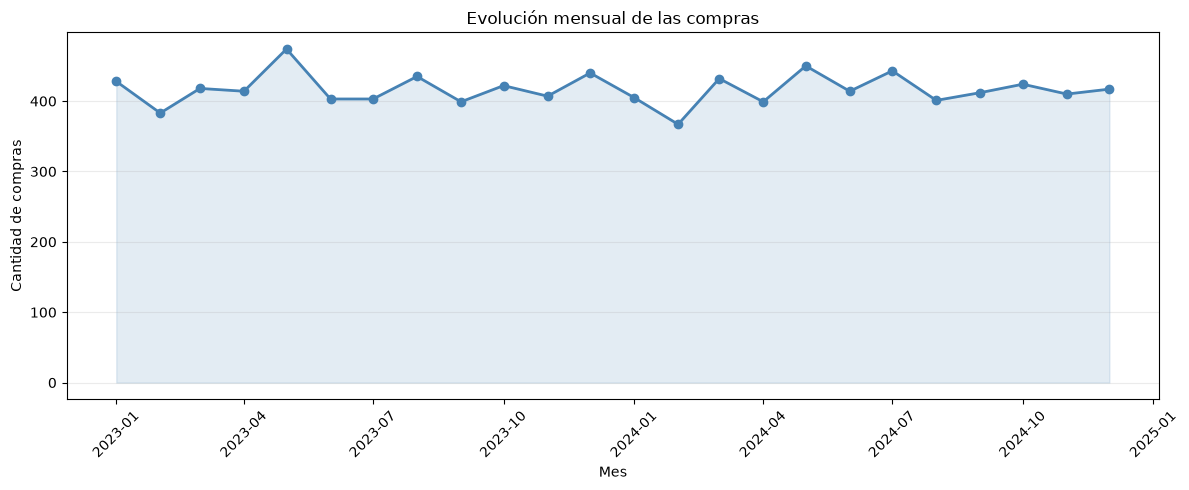

In [6]:
# Agrupamos las transacciones por mes para observar su evolución en el tiempo
compras_mensuales = (
    df_eda
    .set_index("Purchase Date")
    .resample("MS")
    .size()
)
# Mostramos el resumen mensual para poder revisar también los valores exactos
display(compras_mensuales.to_frame(name="Cantidad de compras"))
# Evolución mensual de las transacciones
plt.figure(figsize=(12, 5))
plt.plot(
    compras_mensuales.index,
    compras_mensuales.values,
    marker="o",
    linewidth=2,
    color="steelblue"
)
plt.fill_between(
    compras_mensuales.index,
    compras_mensuales.values,
    alpha=0.15,
    color="steelblue"
)
plt.title("Evolución mensual de las compras")
plt.xlabel("Mes")
plt.ylabel("Cantidad de compras")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El volumen de compras se mantiene bastante estable durante los dos años analizados. No se observa una tendencia sostenida de crecimiento o caída entre 2023 y 2024. El promedio mensual se encuentra cerca de las 417 compras. El mayor volumen aparece en mayo de 2023 con 474 transacciones, mientras que el menor corresponde a febrero de 2024 con 367. A nivel anual, 2023 registra 5.026 compras y 2024 registra 4.974, por lo que la actividad total entre ambos períodos es muy similar. Estos resultados permiten observar estabilidad en el volumen general, aunque todavía no alcanzan para afirmar que exista estacionalidad. Para eso es necesario comparar el comportamiento de los mismos meses entre ambos años.

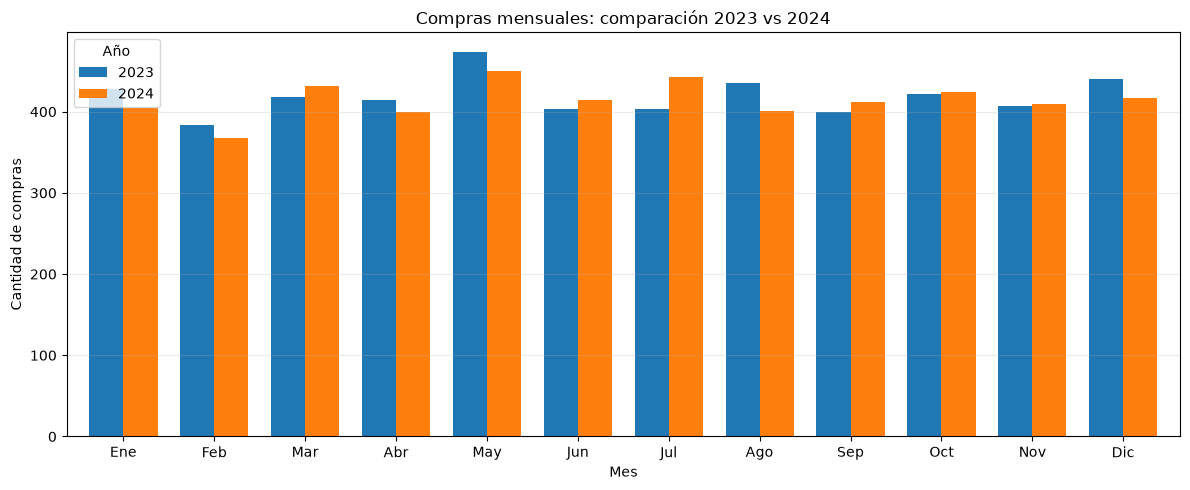

In [7]:
# Extraemos año y mes para comparar el comportamiento mensual entre períodos
df_eda["Año"] = df_eda["Purchase Date"].dt.year
df_eda["Mes"] = df_eda["Purchase Date"].dt.month
# Cantidad de compras por mes y año
compras_mes_año = (
    df_eda
    .groupby(["Mes", "Año"])
    .size()
    .unstack()
)
# Nombres de los meses para facilitar la lectura
nombres_meses = [
    "Ene", "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]
compras_mes_año.index = nombres_meses
# Comparación mensual entre 2023 y 2024
compras_mes_año.plot(
    kind="bar",
    figsize=(12, 5),
    width=0.75
)
plt.title("Compras mensuales: comparación 2023 vs 2024")
plt.xlabel("Mes")
plt.ylabel("Cantidad de compras")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Año")
plt.tight_layout()
plt.show()

In [8]:
# Calculamos la diferencia de compras entre 2024 y 2023 para cada mes
comparacion_mensual = compras_mes_año.copy()
comparacion_mensual["Diferencia"] = (
    comparacion_mensual[2024] - comparacion_mensual[2023]
)
comparacion_mensual["Variación %"] = (
    comparacion_mensual["Diferencia"] / comparacion_mensual[2023] * 100
).round(2)
display(comparacion_mensual)

Año,2023,2024,Diferencia,Variación %
Ene,428,405,-23,-5.37
Feb,383,367,-16,-4.18
Mar,418,432,14,3.35
Abr,414,399,-15,-3.62
May,474,450,-24,-5.06
Jun,403,414,11,2.73
Jul,403,443,40,9.93
Ago,435,401,-34,-7.82
Sep,399,412,13,3.26
Oct,422,424,2,0.47


Comparación entre 2023 y 2024
Al comparar cada mes entre ambos años no aparecen diferencias demasiado grandes en el volumen de compras. La mayor variación positiva se observa en julio de 2024, con un 9,93% más de compras que en julio de 2023. La mayor caída aparece en agosto, con una disminución del 7,82%. En meses como octubre y noviembre la diferencia entre ambos años es menor al 1%. En conjunto, los datos muestran un volumen de transacciones bastante estable entre 2023 y 2024. Algunos meses, como febrero y mayo, presentan niveles similares en ambos años, pero con solo dos períodos anuales no alcanza para afirmar que exista un patrón estacional estable. Por ese motivo, estos comportamientos se toman como señales descriptivas del histórico y no como evidencia suficiente de estacionalidad.

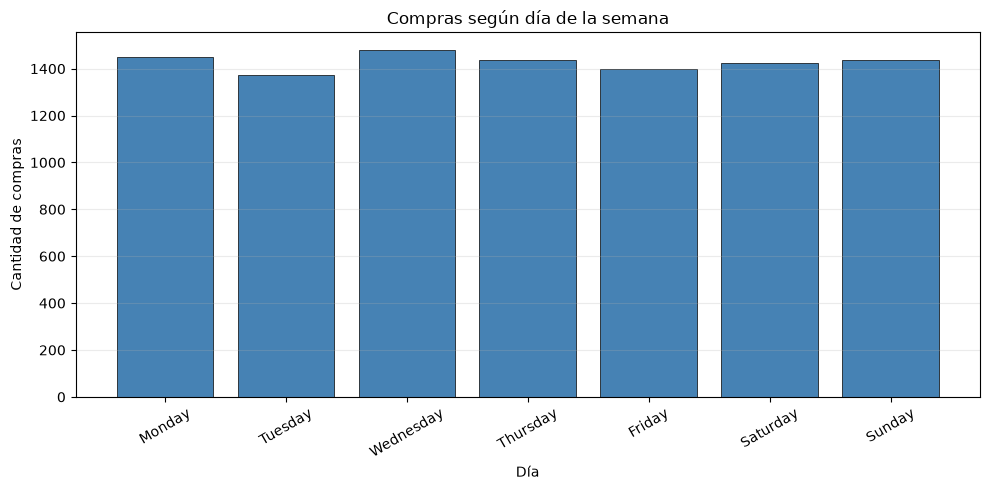

,Cantidad de compras
Dia_semana,
Monday,1448
Tuesday,1374
Wednesday,1481
Thursday,1438
Friday,1399
Saturday,1425
Sunday,1435


In [9]:
# Obtenemos el día de la semana de cada transacción
df_eda["Dia_semana"] = df_eda["Purchase Date"].dt.day_name()
# Definimos el orden natural de los días para evitar que aparezcan ordenados alfabéticamente
orden_dias = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
# Cantidad de compras registradas por día de la semana
compras_por_dia = (
    df_eda["Dia_semana"]
    .value_counts()
    .reindex(orden_dias)
)
# Gráfico de compras por día de la semana
plt.figure(figsize=(10, 5))
plt.bar(
    compras_por_dia.index,
    compras_por_dia.values,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)
plt.title("Compras según día de la semana")
plt.xlabel("Día")
plt.ylabel("Cantidad de compras")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()
display(compras_por_dia.to_frame(name="Cantidad de compras"))

La actividad se distribuye de forma bastante pareja durante toda la semana. El miércoles registra la mayor cantidad de compras con 1.481 transacciones, mientras que el martes presenta el menor volumen con 1.374. La diferencia entre ambos días es relativamente pequeña frente al total del histórico. No aparece un día que concentre claramente la actividad comercial, por lo que en este dataset no se observa un comportamiento semanal fuerte que permita considerar un día específico como dominante. Esto no significa que el día de la semana no pueda aportar información al modelo, pero a nivel descriptivo su efecto sobre el volumen total de compras parece limitado.

## 3. Canal de compra

En este bloque analizamos cómo se distribuyen las transacciones entre compras online y presenciales.
Además de conocer el peso de cada canal, buscamos observar si existen diferencias en volumen de compra, cantidad de productos y comportamiento general entre ambos grupos.

In [10]:
# Cantidad de transacciones registradas en cada canal
compras_por_canal = (
    df_eda["Online/Offline"]
    .value_counts()
)
# Porcentaje que representa cada canal sobre el total
porcentaje_canal = (
    df_eda["Online/Offline"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen del canal de compra
resumen_canal = pd.DataFrame({
    "Cantidad de compras": compras_por_canal,
    "Porcentaje": porcentaje_canal
})
display(resumen_canal)

,Cantidad de compras,Porcentaje
Online/Offline,,
Online,7417,74.17
Offline,2583,25.83


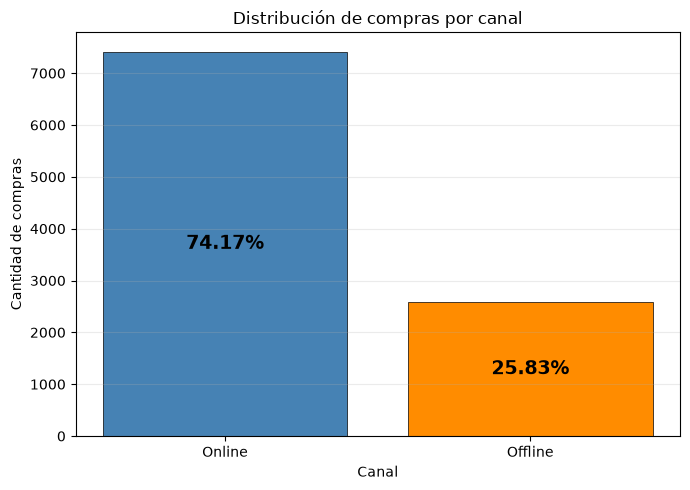

In [11]:
# Colores diferenciados para cada canal de compra
colores_canal = ["steelblue", "darkorange"]
# Gráfico de cantidad de compras por canal
plt.figure(figsize=(7, 5))
barras = plt.bar(
    compras_por_canal.index,
    compras_por_canal.values,
    color=colores_canal,
    edgecolor="black",
    linewidth=0.5
)
plt.title("Distribución de compras por canal")
plt.xlabel("Canal")
plt.ylabel("Cantidad de compras")
plt.grid(axis="y", alpha=0.25)
# Mostramos el porcentaje dentro de cada barra
for barra, canal in zip(barras, compras_por_canal.index):
    porcentaje = porcentaje_canal[canal]

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="center",
        fontsize=14,
        fontweight="bold",
        color="Black"
    )
plt.tight_layout()
plt.show()

In [12]:
# Comparamos el comportamiento de compra entre los canales Online y Offline
resumen_comportamiento_canal = (
    df_eda
    .groupby("Online/Offline")
    .agg(
        transacciones=("Transaction ID", "count"),
        monto_promedio=("Purchase Amount (₹)", "mean"),
        monto_mediano=("Purchase Amount (₹)", "median"),
        cantidad_promedio=("Quantity", "mean"),
        cantidad_mediana=("Quantity", "median")
    )
    .round(2)
)
# Ordenamos los canales para mantener la misma lectura que en el gráfico anterior
resumen_comportamiento_canal = resumen_comportamiento_canal.reindex(
    ["Online", "Offline"]
)
display(resumen_comportamiento_canal)

,transacciones,monto_promedio,monto_mediano,cantidad_promedio,cantidad_mediana
Online/Offline,,,,,
Online,7417,"6,447.02","3,476.00",1.43,1.00
Offline,2583,"6,527.05","3,572.00",1.43,1.00


### Diferencias de comportamiento entre canales
Aunque el canal online concentra el 74,17% de las transacciones, el comportamiento de compra por operación es muy similar entre ambos canales. El monto promedio es de ₹6.447,02 en compras online y ₹6.527,05 en compras offline. La diferencia es pequeña en relación con los valores observados. La mediana también presenta valores cercanos: ₹3.476 y ₹3.572 respectivamente. La cantidad de productos comprados por transacción prácticamente no cambia según el canal: ambos presentan un promedio de 1,43 unidades y una mediana de 1. Por lo tanto, la principal diferencia observada entre los canales está en el volumen de transacciones y no en el tamaño de cada compra.

In [13]:
# Nos quedamos únicamente con las compras realizadas por canal online
compras_online = df_eda[
    df_eda["Online/Offline"] == "Online"
].copy()
# Cantidad de compras registradas por tienda online
compras_por_tienda = (
    compras_online["Online Store"]
    .value_counts()
)
# Porcentaje de participación de cada tienda
porcentaje_tienda = (
    compras_online["Online Store"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_tiendas = pd.DataFrame({
    "Cantidad de compras": compras_por_tienda,
    "Porcentaje": porcentaje_tienda
})
display(resumen_tiendas)

,Cantidad de compras,Porcentaje
Online Store,,
Meesho,1277,17.22
Ajio,1276,17.20
Amazon,1229,16.57
Myntra,1218,16.42
Flipkart,1212,16.34
Nykaa,1205,16.25


### Distribución de las compras online por plataforma
Las 7.417 compras realizadas por canal online se encuentran distribuidas de forma bastante pareja entre las seis plataformas disponibles. Meesho presenta la mayor participación con el 17,22% de las compras online, mientras que Nykaa registra la menor con el 16,25%. La diferencia entre ambas es inferior a un punto porcentual. No se observa una plataforma claramente dominante, por lo que la concentración del canal online no depende de una única tienda.

> **Nota:** el análisis por plataforma se realiza únicamente sobre las compras online. En las compras offline, el dataset no identifica establecimientos físicos individuales y utiliza `In-Store Purchase` como valor estructural en la variable `Online Store`.

## 4. Distribución geográfica de las compras

En este bloque analizamos cómo se distribuyen las transacciones entre las distintas ubicaciones registradas en el dataset.

El objetivo es identificar si existen zonas con una concentración de compras claramente superior al resto y evaluar si la ubicación puede aportar contexto al sistema de recomendación.

In [14]:
# Cantidad de compras registradas en cada ubicación
compras_por_ubicacion = (
    df_eda["Location"]
    .value_counts()
)
# Porcentaje de participación de cada ubicación
porcentaje_ubicacion = (
    df_eda["Location"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_ubicaciones = pd.DataFrame({
    "Cantidad de compras": compras_por_ubicacion,
    "Porcentaje": porcentaje_ubicacion
})
display(resumen_ubicaciones)

,Cantidad de compras,Porcentaje
Location,,
Lucknow,590,5.90
Noida,578,5.78
Bangalore,570,5.70
Kolkata,549,5.49
Nagpur,543,5.43
Patna,541,5.41
Chennai,536,5.36
Bhubaneswar,521,5.21
Mumbai,517,5.17


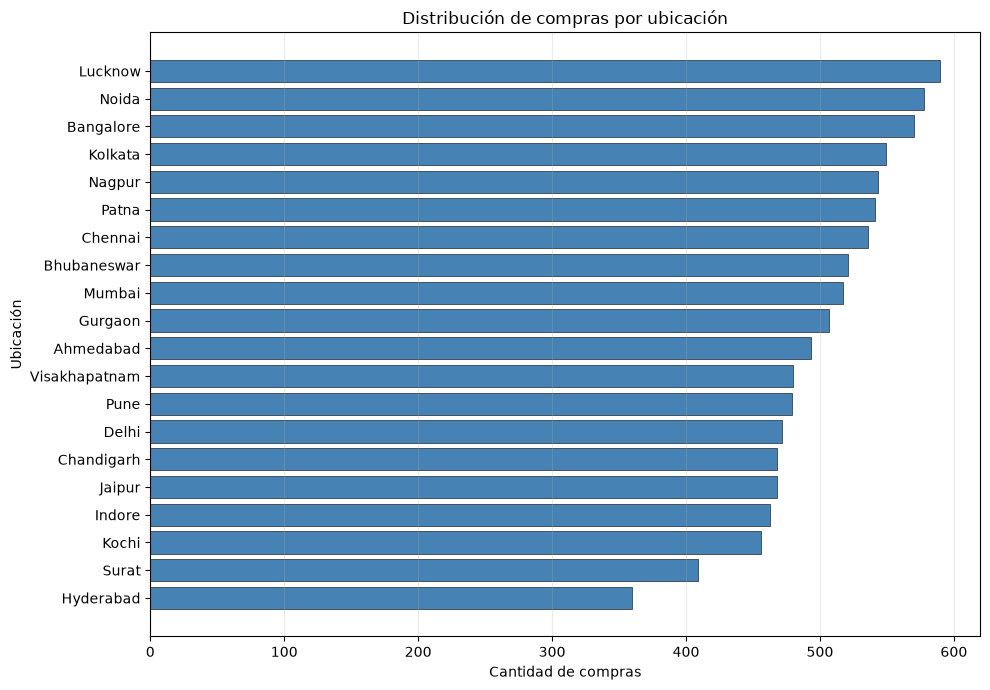

In [15]:
# Ordenamos las ubicaciones de menor a mayor para facilitar la lectura del gráfico
ubicaciones_grafico = compras_por_ubicacion.sort_values()
# Gráfico de cantidad de compras por ubicación
plt.figure(figsize=(10, 7))
plt.barh(
    ubicaciones_grafico.index,
    ubicaciones_grafico.values,
    color="steelblue",
    edgecolor="black",
    linewidth=0.4
)
plt.title("Distribución de compras por ubicación")
plt.xlabel("Cantidad de compras")
plt.ylabel("Ubicación")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Distribución de compras por ubicación

Las compras se encuentran distribuidas entre las 20 ubicaciones sin que una ciudad concentre una proporción dominante del histórico. Lucknow presenta el mayor volumen con 590 compras, equivalente al 5,90% del total, mientras que Hyderabad registra el menor con 360 compras (3,60%). Aunque existen diferencias entre ciudades, la distribución general es relativamente pareja. Esto permite considerar la ubicación como una posible variable de contexto para el recomendador sin que el comportamiento general quede condicionado por una única zona.

In [16]:
# Cantidad de compras Online y Offline en cada ubicación
canal_por_ubicacion = pd.crosstab(
    df_eda["Location"],
    df_eda["Online/Offline"]
)
# Calculamos qué porcentaje representa cada canal dentro de cada ubicación
porcentaje_canal_ubicacion = (
    canal_por_ubicacion
    .div(canal_por_ubicacion.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)
# Ordenamos por porcentaje de compras Online para facilitar la comparación
porcentaje_canal_ubicacion = porcentaje_canal_ubicacion.sort_values(
    "Online",
    ascending=False
)
display(porcentaje_canal_ubicacion)

Online/Offline,Offline,Online
Location,,
Bangalore,21.23,78.77
Mumbai,21.47,78.53
Jaipur,21.79,78.21
Delhi,23.31,76.69
Kochi,23.90,76.10
Lucknow,24.24,75.76
Hyderabad,24.72,75.28
Noida,24.74,75.26
Patna,24.77,75.23


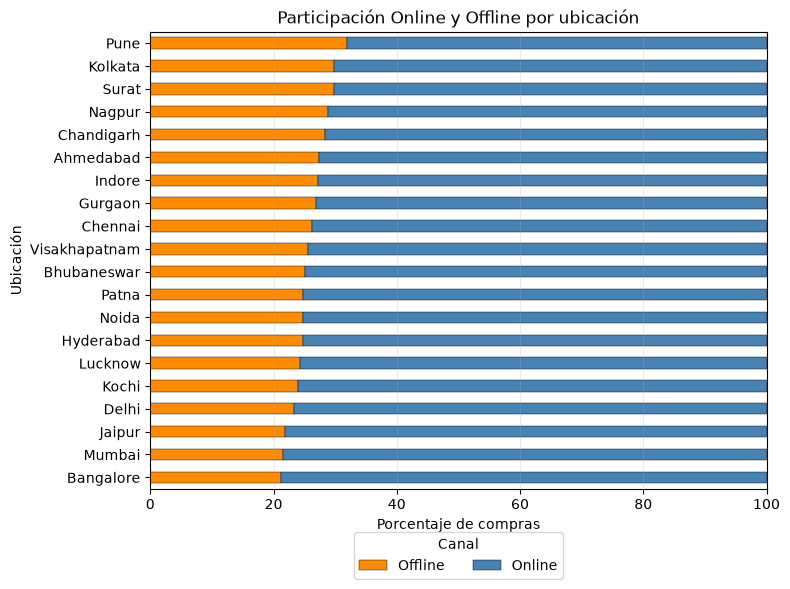

In [17]:
# Gráfico porcentual del canal de compra dentro de cada ubicación
porcentaje_canal_ubicacion.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 6),
    color=["darkorange", "steelblue"],
    edgecolor="black",
    linewidth=0.3
)
plt.title("Participación Online y Offline por ubicación")
plt.xlabel("Porcentaje de compras")
plt.ylabel("Ubicación")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.25)
plt.legend(
    title="Canal",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2
)
plt.tight_layout()
plt.show()

### Relación entre ubicación y canal de compra

El canal online es mayoritario en todas las ubicaciones analizadas, aunque su participación varía entre ciudades. Bangalore presenta la mayor proporción de compras online con un 78,77%, seguida por Mumbai con 78,53% y Jaipur con 78,21%. En el otro extremo, Pune registra un 68,06% de compras online, mientras que Kolkata y Surat se encuentran cerca del 70%. Si bien entre algunas ciudades aparecen diferencias superiores a 10 puntos porcentuales, el patrón general se mantiene: el canal online es mayoritario en todas las ubicaciones. Por lo tanto, la ubicación presenta diferencias descriptivas en la preferencia de canal, pero estas diferencias no permiten concluir por sí solas que exista una asociación fuerte entre ambas variables.

## 5. Categorías y productos

En este bloque analizamos cómo se distribuyen las compras entre las distintas categorías y productos disponibles.

El objetivo es identificar posibles concentraciones dentro del catálogo y observar si algunos productos tienen una presencia claramente superior al resto, algo especialmente importante para evaluar posteriormente un recomendador basado en popularidad.

In [18]:
# Cantidad de compras registradas por categoría
compras_por_categoria = (
    df_eda["Category"]
    .value_counts()
)
# Participación porcentual de cada categoría
porcentaje_categoria = (
    df_eda["Category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_categorias = pd.DataFrame({
    "Cantidad de compras": compras_por_categoria,
    "Porcentaje": porcentaje_categoria
})
display(resumen_categorias)

,Cantidad de compras,Porcentaje
Category,,
Clothing,5004,50.04
Footwear,3395,33.95
Accessories,1601,16.01


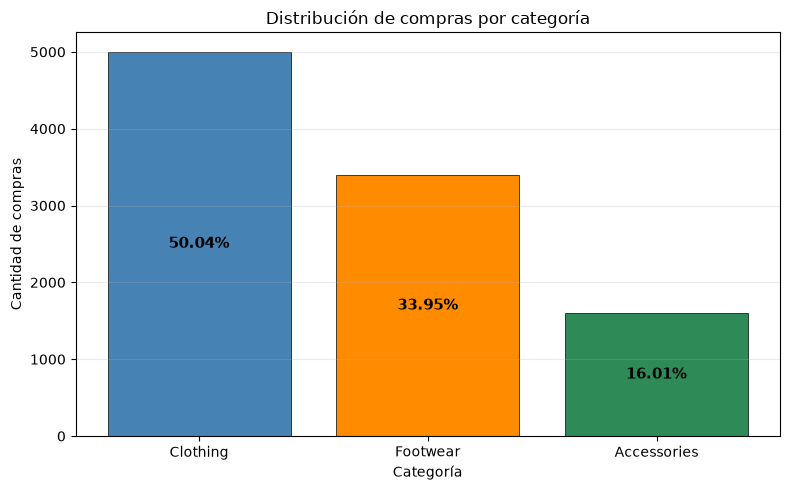

In [19]:
# Colores diferenciados para facilitar la comparación entre categorías
colores_categoria = ["steelblue", "darkorange", "seagreen"]
# Gráfico de distribución de compras por categoría
plt.figure(figsize=(8, 5))
barras = plt.bar(
    compras_por_categoria.index,
    compras_por_categoria.values,
    color=colores_categoria,
    edgecolor="black",
    linewidth=0.5
)
plt.title("Distribución de compras por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de compras")
plt.grid(axis="y", alpha=0.25)
# Mostramos el porcentaje dentro de cada barra
for barra, categoria in zip(barras, compras_por_categoria.index):
    porcentaje = porcentaje_categoria[categoria]

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

### Distribución por categoría

La categoría `Clothing` concentra el 50,04% de las compras del histórico, seguida por `Footwear` con 33,95% y `Accessories` con 16,01%. Esto muestra una concentración clara a nivel de categoría, aunque por sí sola no alcanza para concluir que exista un sesgo fuerte en el catálogo. Para evaluar si esa concentración puede afectar a un recomendador basado en popularidad es necesario bajar al nivel de producto y comprobar si existe uno o pocos artículos que dominen las compras.

In [20]:
# Cantidad de compras registradas por producto
compras_por_producto = (
    df_eda["Item Purchased"]
    .value_counts()
)
# Participación porcentual de cada producto
porcentaje_producto = (
    df_eda["Item Purchased"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_productos = pd.DataFrame({
    "Cantidad de compras": compras_por_producto,
    "Porcentaje": porcentaje_producto
})
display(resumen_productos)

,Cantidad de compras,Porcentaje
Item Purchased,,
Kurta,870,8.70
Running Shoes,861,8.61
Saree,846,8.46
Sneakers,817,8.17
Jacket,676,6.76
T-shirt,645,6.45
Shorts,604,6.04
Hoodie,417,4.17
Sandals,371,3.71


### Distribución por producto

Al bajar el análisis al nivel de producto, la concentración observada en las categorías se reparte entre distintos artículos. `Kurta` es el producto más frecuente y representa el 8,70% de las compras. Le siguen `Running Shoes` con 8,61%, `Saree` con 8,46% y `Sneakers` con 8,17%. Los cinco productos más frecuentes concentran en conjunto el 40,70% de las transacciones, pero ninguno de ellos domina individualmente el histórico. Por lo tanto, existe una diferencia de popularidad entre productos, pero no se observa un único artículo con una participación lo suficientemente alta como para concluir por sí solo que el recomendador quedará condicionado por un producto dominante. Esta distribución deberá compararse posteriormente contra un baseline de popularidad para medir cuánto valor adicional aporta el modelo de recomendación.

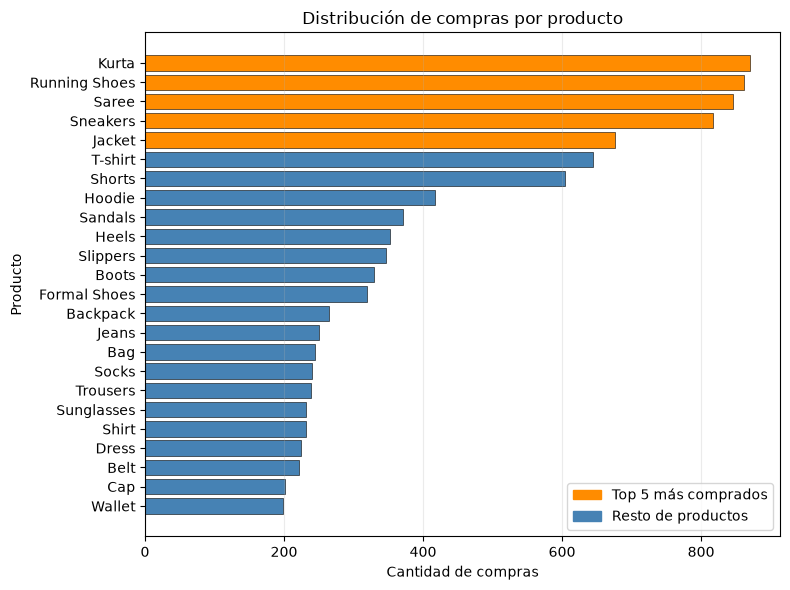

In [21]:
# Ordenamos los productos de menor a mayor para facilitar la lectura
productos_grafico = compras_por_producto.sort_values()
# Destacamos los cinco productos con mayor cantidad de compras
top_5_productos = compras_por_producto.head(5).index
colores_producto = [
    "darkorange" if producto in top_5_productos else "steelblue"
    for producto in productos_grafico.index
]
# Gráfico de cantidad de compras por producto
plt.figure(figsize=(8, 6))
plt.barh(
    productos_grafico.index,
    productos_grafico.values,
    color=colores_producto,
    edgecolor="black",
    linewidth=0.4
)
plt.title("Distribución de compras por producto")
plt.xlabel("Cantidad de compras")
plt.ylabel("Producto")
plt.grid(axis="x", alpha=0.25)
# Referencia de colores
leyenda_producto = [
    Patch(color="darkorange", label="Top 5 más comprados"),
    Patch(color="steelblue", label="Resto de productos")
]
plt.legend(handles=leyenda_producto)
plt.tight_layout()
plt.show()

### Análisis de precios y popularidad

El siguiente gráfico muestra el precio unitario de los productos y permite observar un aspecto importante para el sistema de recomendación. Aunque la popularidad puede ser útil para recomendar productos, utilizarla como único criterio podría llevarnos a no recomendar productos con precios más altos.

Esto se debe a que los productos de mayor precio suelen encontrarse en la long tail (cola larga) de la distribución: tienen una menor frecuencia de compra y, por lo tanto, aparecen con menor frecuencia entre los productos populares. En nuestro caso, la recomendación basada únicamente en popularidad incluye solo un producto perteneciente a esta zona de precios altos.

Por esta razón, considerar únicamente la popularidad podría sesgar las recomendaciones hacia productos de mayor frecuencia de compra, dejando fuera productos de mayor precio que, aunque sean menos populares, pueden representar una oportunidad importante para el negocio.

En consecuencia, resulta conveniente combinar la popularidad con otras variables, como el precio, la similitud entre productos y las características del cliente, para obtener recomendaciones más equilibradas.

In [46]:
item_df= df.drop_duplicates(subset= ['Item Purchased'])
item_df['unit_price'] = df['Purchase Amount (₹)']/df['Quantity']
item_pricedf= item_df[['Item Purchased','unit_price']].sort_values(by= 'unit_price')


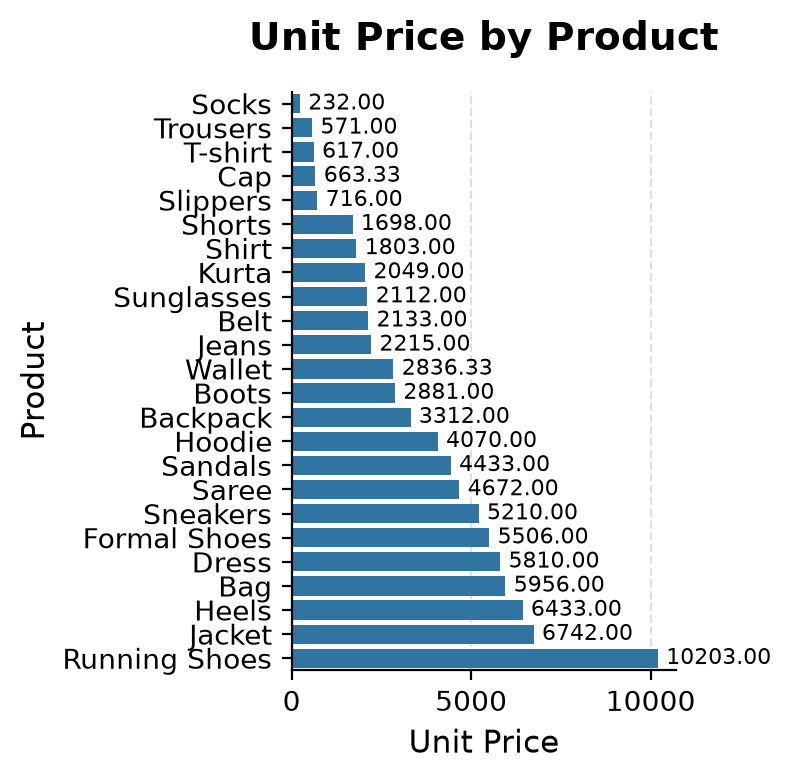

In [45]:
plt.figure(figsize=(4, 4), dpi=200)

ax = sns.barplot(
    data=item_pricedf,
    x='unit_price',
    y='Item Purchased',
    orient='h'
)

# Title and labels
ax.set_title('Unit Price by Product', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Unit Price', fontsize=11)
ax.set_ylabel('Product', fontsize=11)

# Grid
ax.grid(axis='x', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Add price values to the bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=8
    )

# Clean up
sns.despine()
plt.tight_layout()

plt.show()

### Lectura general de categorías y productos

A nivel de categoría existe una concentración clara en `Clothing`, que representa el 50,04% de las transacciones. Sin embargo, al analizar los productos individualmente esa concentración se distribuye entre distintos artículos. El producto más frecuente es `Kurta` con el 8,70% de las compras, seguido muy de cerca por `Running Shoes`, `Saree` y `Sneakers`. Los cinco productos con mayor cantidad de compras concentran el 40,70% del histórico, pero ningún producto domina individualmente el dataset. Esto es relevante para ReActiva porque existe suficiente diferencia de popularidad como para construir un baseline basado en productos frecuentes, pero no se observa un único artículo que explique por sí solo una parte excesiva de las recomendaciones. Más adelante será necesario comparar ese baseline de popularidad contra el modelo principal para determinar si el recomendador aporta personalización real.

## 6. Marcas y talles

En este bloque analizamos la distribución de las compras entre las distintas marcas y talles disponibles.

El objetivo es observar si existen marcas con una participación claramente superior al resto y entender cómo se distribuyen los talles dentro del catálogo, teniendo en cuenta que estas variables pueden aportar contexto al sistema de recomendación.

In [22]:
# Cantidad de compras registradas por marca
compras_por_marca = (
    df_eda["Brand"]
    .value_counts()
)
# Participación porcentual de cada marca
porcentaje_marca = (
    df_eda["Brand"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_marcas = pd.DataFrame({
    "Cantidad de compras": compras_por_marca,
    "Porcentaje": porcentaje_marca
})
display(resumen_marcas)

,Cantidad de compras,Porcentaje
Brand,,
Max,1223,12.23
Puma,1177,11.77
HRX,835,8.35
Adidas,829,8.29
Nike,828,8.28
Zara,676,6.76
FabIndia,600,6.00
Levis,578,5.78
Biba,557,5.57


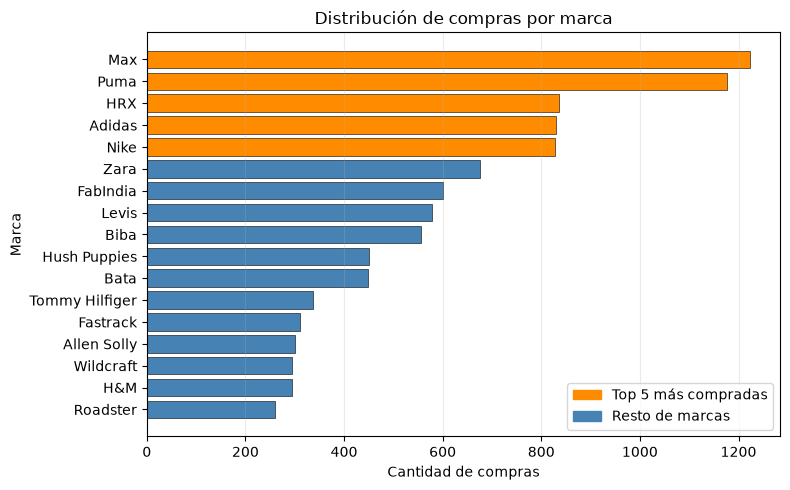

In [23]:
# Ordenamos las marcas de menor a mayor para facilitar la lectura
marcas_grafico = compras_por_marca.sort_values()
# Destacamos las cinco marcas con mayor cantidad de compras
top_5_marcas = compras_por_marca.head(5).index
colores_marca = [
    "darkorange" if marca in top_5_marcas else "steelblue"
    for marca in marcas_grafico.index
]
# Gráfico de cantidad de compras por marca
plt.figure(figsize=(8, 5))
plt.barh(
    marcas_grafico.index,
    marcas_grafico.values,
    color=colores_marca,
    edgecolor="black",
    linewidth=0.4
)
plt.title("Distribución de compras por marca")
plt.xlabel("Cantidad de compras")
plt.ylabel("Marca")
plt.grid(axis="x", alpha=0.25)
# Referencia de colores
leyenda_marca = [
    Patch(color="darkorange", label="Top 5 más compradas"),
    Patch(color="steelblue", label="Resto de marcas")
]
plt.legend(handles=leyenda_marca)
plt.tight_layout()
plt.show()

### Distribución por marca

Las compras se encuentran repartidas entre 17 marcas. `Max` presenta la mayor participación con el 12,23%, seguida por `Puma` con el 11,77%. Las cinco marcas más frecuentes concentran aproximadamente el 48,92% de las compras, pero ninguna marca domina individualmente el histórico. Esto muestra una concentración moderada en algunas marcas, aunque existe suficiente variedad como para que la marca pueda utilizarse como información de contexto dentro del sistema de recomendación.

In [24]:
# Cantidad de compras registradas por talle
compras_por_talle = (
    df_eda["Size"]
    .value_counts()
)
# Participación porcentual de cada talle
porcentaje_talle = (
    df_eda["Size"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
# Tabla resumen
resumen_talles = pd.DataFrame({
    "Cantidad de compras": compras_por_talle,
    "Porcentaje": porcentaje_talle
})
display(resumen_talles)

,Cantidad de compras,Porcentaje
Size,,
Free Size,1262,12.62
M,1000,10.00
L,899,8.99
XS,877,8.77
S,865,8.65
XL,865,8.65
XXL,837,8.37
10,603,6.03
9,576,5.76


In [25]:
# Cruzamos categoría y talle para entender qué escalas de tamaño aparecen dentro de cada tipo de producto
talles_por_categoria = pd.crosstab(
    df_eda["Category"],
    df_eda["Size"]
)
display(talles_por_categoria)

Size,10,11,6,7,8,9,Free Size,L,M,S,XL,XS,XXL
Category,,,,,,,,,,,,,
Accessories,0,0,0,0,0,0,1262,62,206,71,0,0,0
Clothing,0,0,0,0,0,0,0,837,794,794,865,877,837
Footwear,603,565,576,537,538,576,0,0,0,0,0,0,0


In [26]:
# Calculamos la distribución porcentual de los talles dentro de cada categoría
porcentaje_talles_categoria = (
    talles_por_categoria
    .div(talles_por_categoria.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)
display(porcentaje_talles_categoria)

Size,10,11,6,7,8,9,Free Size,L,M,S,XL,XS,XXL
Category,,,,,,,,,,,,,
Accessories,0.00,0.00,0.00,0.00,0.00,0.00,78.83,3.87,12.87,4.43,0.00,0.00,0.00
Clothing,0.00,0.00,0.00,0.00,0.00,0.00,0.00,16.73,15.87,15.87,17.29,17.53,16.73
Footwear,17.76,16.64,16.97,15.82,15.85,16.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00


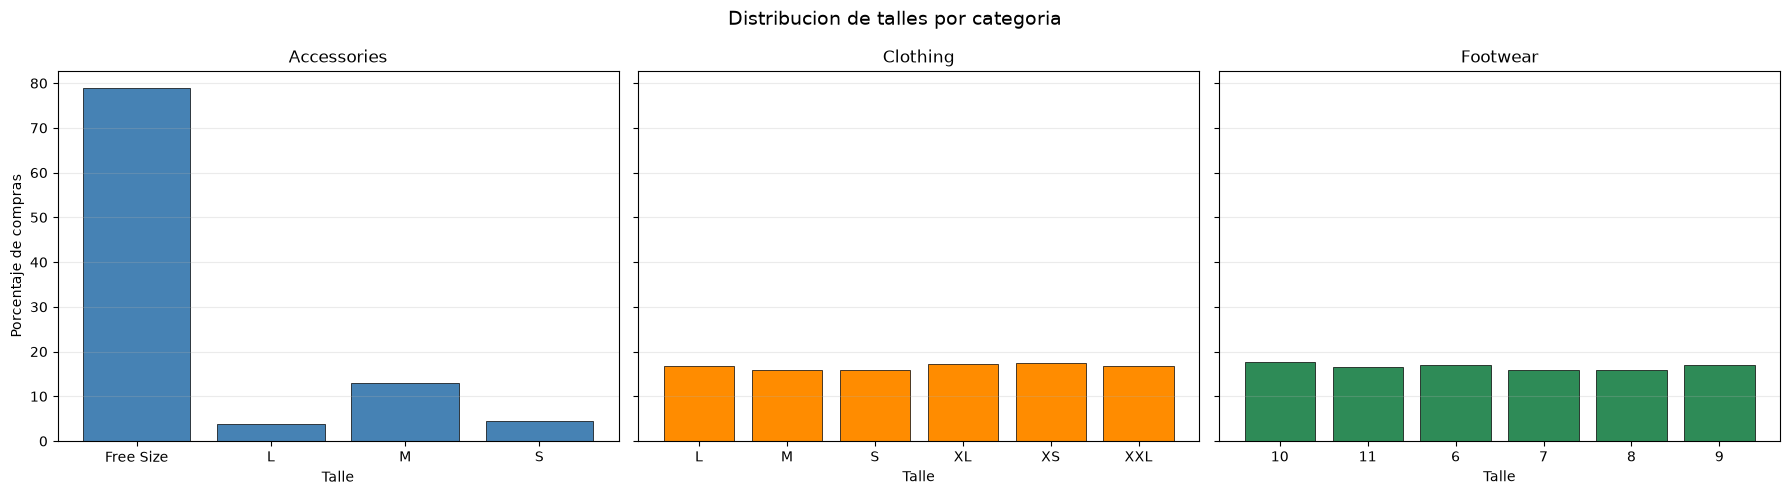

In [27]:
# =========================
# Distribucion de talles por categoria
# =========================
talles_accessories = porcentaje_talles_categoria.loc["Accessories"]
talles_accessories = talles_accessories[talles_accessories > 0]
talles_clothing = porcentaje_talles_categoria.loc["Clothing"]
talles_clothing = talles_clothing[talles_clothing > 0]
talles_footwear = porcentaje_talles_categoria.loc["Footwear"]
talles_footwear = talles_footwear[talles_footwear > 0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
# Accessories
axes[0].bar(
    talles_accessories.index,
    talles_accessories.values,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)
axes[0].set_title("Accessories")
axes[0].set_xlabel("Talle")
axes[0].set_ylabel("Porcentaje de compras")
axes[0].grid(axis="y", alpha=0.25)
# Clothing
axes[1].bar(
    talles_clothing.index,
    talles_clothing.values,
    color="darkorange",
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Clothing")
axes[1].set_xlabel("Talle")
axes[1].grid(axis="y", alpha=0.25)
# Footwear
axes[2].bar(
    talles_footwear.index,
    talles_footwear.values,
    color="seagreen",
    edgecolor="black",
    linewidth=0.5
)
axes[2].set_title("Footwear")
axes[2].set_xlabel("Talle")
axes[2].grid(axis="y", alpha=0.25)
fig.suptitle("Distribucion de talles por categoria", fontsize=14)
plt.tight_layout()
plt.show()

### Distribución de talles por categoría

La variable `Size` no puede interpretarse de forma global porque utiliza escalas diferentes según la categoría del producto. En `Accessories`, el 78,83% de las compras corresponde a `Free Size`, por lo que existe una concentración fuerte en ese tipo de talle. En `Clothing`, en cambio, los talles se distribuyen de forma bastante pareja entre `XS`, `S`, `M`, `L`, `XL` y `XXL`, sin que ninguno domine claramente. Algo similar ocurre en `Footwear`, donde los talles numéricos entre 6 y 11 presentan participaciones cercanas entre sí. Por lo tanto, `Size` puede aportar información al sistema de recomendación, pero debe interpretarse siempre en conjunto con la categoría del producto.

## 7. Perfil de clientes

En este bloque analizamos algunas características generales de los clientes presentes en el histórico.

El objetivo es observar cómo se distribuyen las edades y el género, identificando posibles concentraciones que puedan aportar contexto al sistema de recomendación sin asumir que estas variables explican por sí solas el comportamiento de compra.

In [28]:
# Verificamos que edad y género sean consistentes para cada cliente
consistencia_clientes = (
    df_eda
    .groupby("Customer ID")[["Age", "Gender"]]
    .nunique()
)
clientes_edad_inconsistente = (
    consistencia_clientes["Age"] > 1
).sum()
clientes_genero_inconsistente = (
    consistencia_clientes["Gender"] > 1
).sum()
print(f"Clientes con más de una edad registrada: {clientes_edad_inconsistente}")
print(f"Clientes con más de un género registrado: {clientes_genero_inconsistente}")
# Tomamos una sola observación por cliente para analizar su perfil
perfil_clientes = (
    df_eda[
        ["Customer ID", "Age", "Gender"]
    ]
    .drop_duplicates(subset="Customer ID")
)
print(f"\nClientes analizados: {len(perfil_clientes):,}")
# Resumen de edad sobre clientes únicos
resumen_edad = (
    perfil_clientes["Age"]
    .describe()
    .round(2)
)
print("\nResumen de edad")
display(
    resumen_edad.to_frame(name="Valor")
)
# Distribución de clientes por género
clientes_por_genero = (
    perfil_clientes["Gender"]
    .value_counts()
)
porcentaje_genero = (
    perfil_clientes["Gender"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
resumen_genero = pd.DataFrame({
    "Cantidad de clientes": clientes_por_genero,
    "Porcentaje": porcentaje_genero
})

print("\nDistribución por género")
display(resumen_genero)

Clientes con más de una edad registrada: 0
Clientes con más de un género registrado: 0

Clientes analizados: 3,291

Resumen de edad


,Valor
count,"3,291.00"
mean,40.96
std,13.46
min,18.00
25%,29.00
50%,41.00
75%,52.00
max,64.00



Distribución por género


,Cantidad de clientes,Porcentaje
Gender,,
Female,1601,48.65
Male,1576,47.89
Other,114,3.46


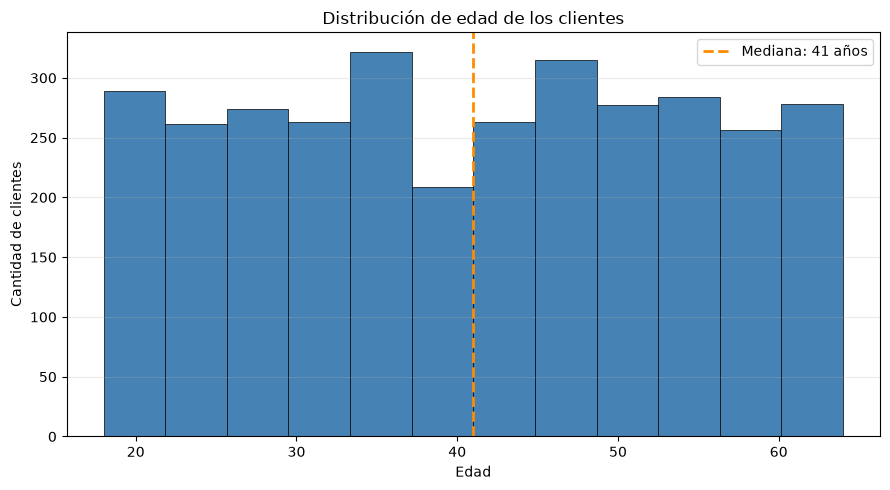

In [29]:
# Distribución de edad tomando una sola observación por cliente
plt.figure(figsize=(9, 5))
plt.hist(
    perfil_clientes["Age"],
    bins=12,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)
# Marcamos la edad mediana como referencia
plt.axvline(
    perfil_clientes["Age"].median(),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {perfil_clientes['Age'].median():.0f} años"
)
plt.title("Distribución de edad de los clientes")
plt.xlabel("Edad")
plt.ylabel("Cantidad de clientes")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Perfil general de los clientes

El análisis se realizó sobre los 3.291 clientes únicos del histórico, tomando una sola observación por `Customer ID`. Antes de construir el perfil se verificó que ningún cliente tuviera más de una edad o género registrado, por lo que las variables se mantienen consistentes entre sus distintas transacciones. La edad de los clientes se encuentra entre 18 y 64 años, con una media de 40,96 años y una mediana de 41. La distribución es bastante pareja a lo largo del rango observado y no aparece un grupo etario claramente dominante. En cuanto al género, `Female` representa el 48,65% de los clientes y `Male` el 47,89%, mientras que `Other` corresponde al 3,46%. Por lo tanto, a nivel descriptivo no se observa una concentración fuerte por edad o género. Estas variables pueden aportar contexto al sistema de recomendación, pero el histórico no muestra un segmento demográfico que domine claramente la base de clientes.

## 8. Importes, cantidades y descuentos

En este bloque analizamos el comportamiento económico de las transacciones.

El objetivo es observar cómo se distribuyen los montos de compra, las cantidades adquiridas y los descuentos aplicados, identificando diferencias relevantes sin asumir que los valores extremos representan errores.

In [30]:
# Resumen de las principales variables económicas de las transacciones
resumen_economico = df_eda[
    [
        "Purchase Amount (₹)",
        "Quantity",
        "Discount (%)"
    ]
].describe().round(2)
display(resumen_economico)

,Purchase Amount (₹),Quantity,Discount (%)
count,"10,000.00","10,000.00","10,000.00"
mean,"6,467.69",1.43,8.70
std,"8,777.62",0.73,7.28
min,107.00,1.00,0.00
25%,"1,659.00",1.00,4.00
50%,"3,491.00",1.00,8.00
75%,"7,544.25",2.00,12.00
max,"113,920.00",4.00,69.00


In [31]:
# Percentiles altos del monto de compra para entender mejor los valores extremos
percentiles_monto = df_eda["Purchase Amount (₹)"].quantile(
    [0.90, 0.95, 0.99]
)
print("Percentiles del monto de compra")
display(
    percentiles_monto.to_frame(name="Monto (₹)")
)
# Distribución de la cantidad de productos por transacción
distribucion_cantidad = (
    df_eda["Quantity"]
    .value_counts()
    .sort_index()
)
print("\nCantidad de productos por transacción")
display(
    distribucion_cantidad.to_frame(name="Cantidad de compras")
)
# Distribución básica de los descuentos más frecuentes
descuentos_frecuentes = (
    df_eda["Discount (%)"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)
print("\n10 descuentos más frecuentes")
display(
    descuentos_frecuentes.to_frame(name="Cantidad de compras")
)

Percentiles del monto de compra


,Monto (₹)
0.90,"15,674.40"
0.95,"22,694.60"
0.99,"44,459.69"



Cantidad de productos por transacción


,Cantidad de compras
Quantity,
1,6947
2,2053
3,794
4,206



10 descuentos más frecuentes


,Cantidad de compras
Discount (%),
6,664
4,650
9,640
8,640
0,633
3,621
5,618
1,593
2,580


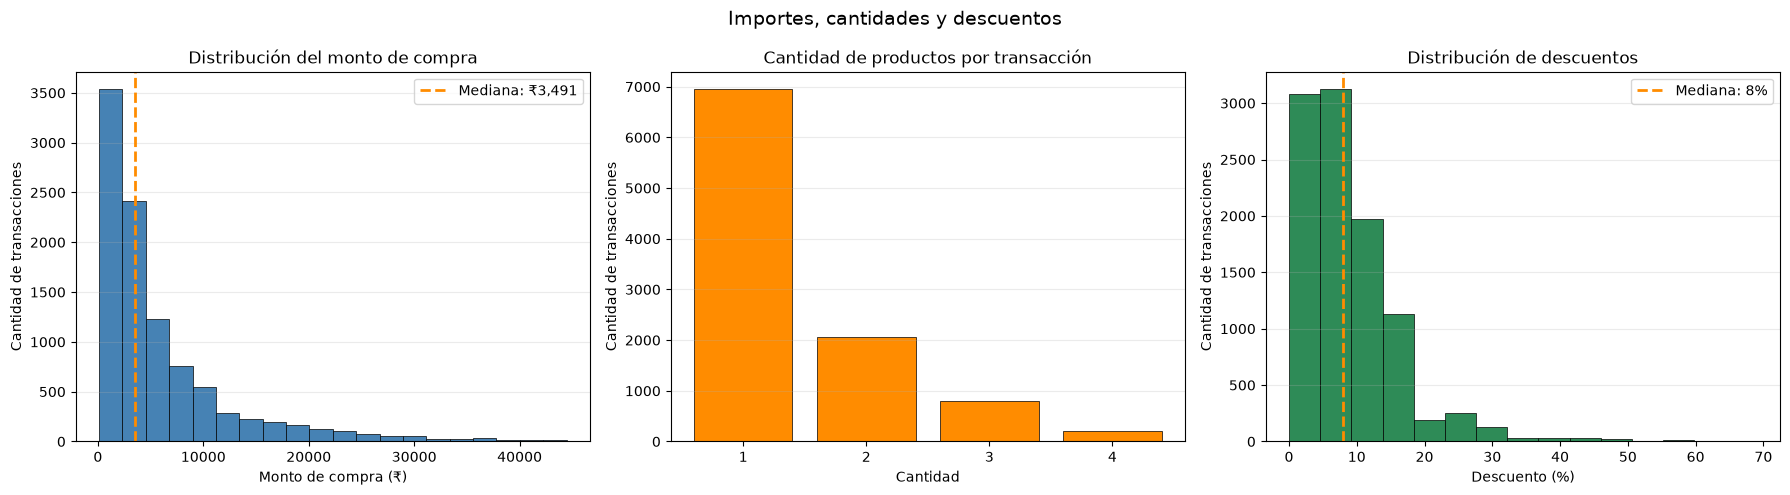

In [32]:
# =========================
# Comportamiento económico de las transacciones
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# -------------------------
# Monto de compra
# -------------------------
# Para visualizar mejor la zona donde se concentra la mayoría de las compras, mostramos hasta el percentil 99 sin eliminar datos del dataframe.
limite_monto = df_eda["Purchase Amount (₹)"].quantile(0.99)

axes[0].hist(
    df_eda.loc[
        df_eda["Purchase Amount (₹)"] <= limite_monto,
        "Purchase Amount (₹)"
    ],
    bins=20,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)
axes[0].axvline(
    df_eda["Purchase Amount (₹)"].median(),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: ₹{df_eda['Purchase Amount (₹)'].median():,.0f}"
)
axes[0].set_title("Distribución del monto de compra")
axes[0].set_xlabel("Monto de compra (₹)")
axes[0].set_ylabel("Cantidad de transacciones")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()
# -------------------------
# Cantidad de productos
# -------------------------
axes[1].bar(
    distribucion_cantidad.index,
    distribucion_cantidad.values,
    color="darkorange",
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Cantidad de productos por transacción")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Cantidad de transacciones")
axes[1].set_xticks(distribucion_cantidad.index)
axes[1].grid(axis="y", alpha=0.25)
# -------------------------
# Descuentos
# -------------------------
axes[2].hist(
    df_eda["Discount (%)"],
    bins=15,
    color="seagreen",
    edgecolor="black",
    linewidth=0.5
)
axes[2].axvline(
    df_eda["Discount (%)"].median(),
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label=f"Mediana: {df_eda['Discount (%)'].median():.0f}%"
)
axes[2].set_title("Distribución de descuentos")
axes[2].set_xlabel("Descuento (%)")
axes[2].set_ylabel("Cantidad de transacciones")
axes[2].grid(axis="y", alpha=0.25)
axes[2].legend()
fig.suptitle(
    "Importes, cantidades y descuentos",
    fontsize=14
)
plt.tight_layout()
plt.show()

### Comportamiento económico de las transacciones

El monto de compra presenta una distribución asimétrica hacia valores altos. La mediana es de ₹3.491, mientras que el promedio alcanza ₹6.467,69, diferencia que se explica por la presencia de compras de mayor importe en la cola de la distribución. El 90% de las transacciones registra montos inferiores a ₹15.674,40, el 95% se encuentra por debajo de ₹22.694,60 y el 99% por debajo de ₹44.459,69. Para facilitar la lectura del gráfico se visualizaron los montos hasta el percentil 99. Las transacciones superiores a ese valor continúan formando parte del dataset y no fueron eliminadas ni modificadas. En cuanto a la cantidad comprada, 6.947 transacciones corresponden a una sola unidad, por lo que la mayor parte de las operaciones presenta un volumen bajo de productos. Los descuentos también se concentran principalmente en valores bajos, con una mediana del 8%, aunque existen operaciones con porcentajes considerablemente superiores. En conjunto, el histórico muestra compras generalmente pequeñas en cantidad y monto, combinadas con un grupo reducido de operaciones de mayor valor.

## 9. Devoluciones, suscripción y medios de pago

En este bloque analizamos algunas variables vinculadas al comportamiento posterior a la compra y a la forma en que los clientes realizan sus transacciones.

El objetivo es observar la proporción de devoluciones, el peso de los clientes suscriptos y la distribución de los distintos medios de pago, buscando patrones que puedan aportar contexto al sistema de recomendación.

In [33]:
# =========================
# Devoluciones
# =========================
devoluciones = df_eda["Return Status"].value_counts()
porcentaje_devoluciones = (
    df_eda["Return Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
resumen_devoluciones = pd.DataFrame({
    "Cantidad de compras": devoluciones,
    "Porcentaje": porcentaje_devoluciones
})
# =========================
# Suscripción
# =========================
suscripciones = df_eda["Subscription Status"].value_counts()
porcentaje_suscripciones = (
    df_eda["Subscription Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
resumen_suscripciones = pd.DataFrame({
    "Cantidad de compras": suscripciones,
    "Porcentaje": porcentaje_suscripciones
})
# =========================
# Medios de pago
# =========================
pagos = df_eda["Payment Method"].value_counts()
porcentaje_pagos = (
    df_eda["Payment Method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)
resumen_pagos = pd.DataFrame({
    "Cantidad de compras": pagos,
    "Porcentaje": porcentaje_pagos
})
print("Devoluciones")
display(resumen_devoluciones)
print("\nSuscripción")
display(resumen_suscripciones)
print("\nMedios de pago")
display(resumen_pagos)

Devoluciones


,Cantidad de compras,Porcentaje
Return Status,,
Not Returned,8249,82.49
Returned,1751,17.51



Suscripción


,Cantidad de compras,Porcentaje
Subscription Status,,
No,7043,70.43
Yes,2957,29.57



Medios de pago


,Cantidad de compras,Porcentaje
Payment Method,,
UPI,4279,42.79
Credit Card,1975,19.75
Debit Card,1420,14.20
Cash on Delivery,1091,10.91
Cash,535,5.35
Net Banking,355,3.55
Wallet,345,3.45


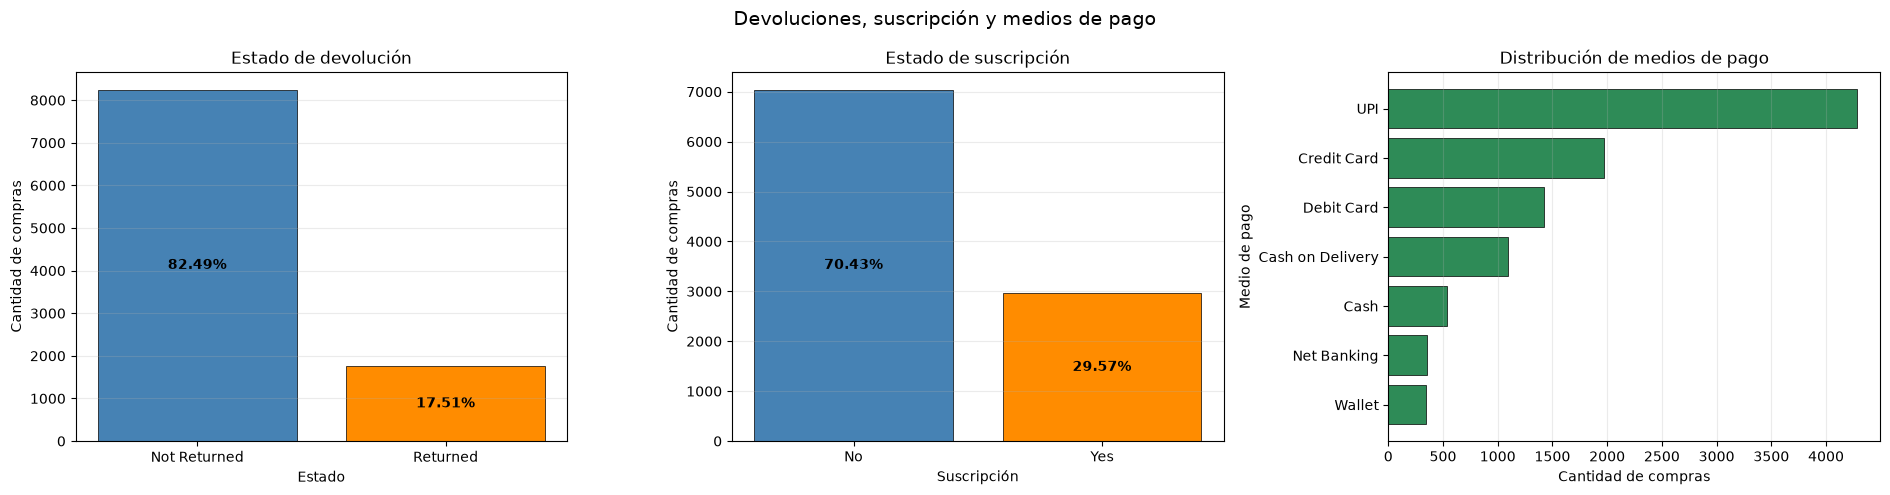

In [34]:
# =========================
# Devoluciones, suscripción y medios de pago
# =========================
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
# -------------------------
# Devoluciones
# -------------------------
colores_devolucion = ["steelblue", "darkorange"]
barras = axes[0].bar(
    devoluciones.index,
    devoluciones.values,
    color=colores_devolucion,
    edgecolor="black",
    linewidth=0.5
)
axes[0].set_title("Estado de devolución")
axes[0].set_xlabel("Estado")
axes[0].set_ylabel("Cantidad de compras")
axes[0].grid(axis="y", alpha=0.25)
# Mostramos el porcentaje dentro de cada barra
for barra, estado in zip(barras, devoluciones.index):
    porcentaje = porcentaje_devoluciones[estado]
    axes[0].text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )
# -------------------------
# Suscripción
# -------------------------
colores_suscripcion = ["steelblue", "darkorange"]
barras = axes[1].bar(
    suscripciones.index,
    suscripciones.values,
    color=colores_suscripcion,
    edgecolor="black",
    linewidth=0.5
)
axes[1].set_title("Estado de suscripción")
axes[1].set_xlabel("Suscripción")
axes[1].set_ylabel("Cantidad de compras")
axes[1].grid(axis="y", alpha=0.25)
# Mostramos el porcentaje dentro de cada barra
for barra, estado in zip(barras, suscripciones.index):
    porcentaje = porcentaje_suscripciones[estado]
    axes[1].text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )
# -------------------------
# Medios de pago
# -------------------------
pagos_grafico = pagos.sort_values()
axes[2].barh(
    pagos_grafico.index,
    pagos_grafico.values,
    color="seagreen",
    edgecolor="black",
    linewidth=0.5
)
axes[2].set_title("Distribución de medios de pago")
axes[2].set_xlabel("Cantidad de compras")
axes[2].set_ylabel("Medio de pago")
axes[2].grid(axis="x", alpha=0.25)
fig.suptitle(
    "Devoluciones, suscripción y medios de pago",
    fontsize=14
)
plt.tight_layout()
plt.show()

### Devoluciones, suscripción y medios de pago

El 17,51% de las compras del histórico registra una devolución, mientras que el 82,49% restante no fue devuelto. En cuanto a la suscripción, el 29,57% de las transacciones corresponde a clientes con suscripción activa y el 70,43% a clientes no suscriptos. La mayor concentración dentro de este bloque aparece en el medio de pago: `UPI` representa el 42,79% de las compras, seguido por `Credit Card` con 19,75% y `Debit Card` con 14,20%. Estos resultados describen el comportamiento observado en el histórico, pero no permiten afirmar por sí solos que la suscripción, el medio de pago o la devolución sean causa de una mayor o menor probabilidad de compra. Además, no todas estas variables pueden utilizarse directamente como información predictiva de una transacción: `Return Status` se conoce después de realizada la compra y el medio de pago de la transacción actual tampoco necesariamente está disponible en el momento de generar una recomendación. Su posible utilización deberá limitarse a información histórica disponible antes del momento de predicción, evitando incorporar fuga de información temporal.

## 10. Cargo de envío

En este bloque analizamos `Shipping Charge (₹)` únicamente como el cargo de envío cobrado al cliente.

No se interpreta esta variable como costo logístico, costo operativo ni margen de la empresa, ya que el dataset no contiene esa información.

In [35]:
# Separamos las compras online, donde el cargo de envío puede tener sentido comercial
envios_online = df_eda[
    df_eda["Online/Offline"] == "Online"
].copy()
# Resumen del cargo de envío en compras online
resumen_envio = (
    envios_online["Shipping Charge (₹)"]
    .describe()
    .round(2)
)
# Valores observados y frecuencia
distribucion_envio = (
    envios_online["Shipping Charge (₹)"]
    .value_counts()
    .sort_index()
)
print("Resumen del cargo de envío en compras online")
display(resumen_envio.to_frame(name="Valor"))
print("\nDistribución de cargos de envío")
display(
    distribucion_envio.to_frame(name="Cantidad de compras")
)

Resumen del cargo de envío en compras online


,Valor
count,"7,417.00"
mean,27.60
std,30.55
min,0.00
25%,0.00
50%,40.00
75%,40.00
max,99.00



Distribución de cargos de envío


,Cantidad de compras
Shipping Charge (₹),
0,3613
40,2219
60,1050
99,535


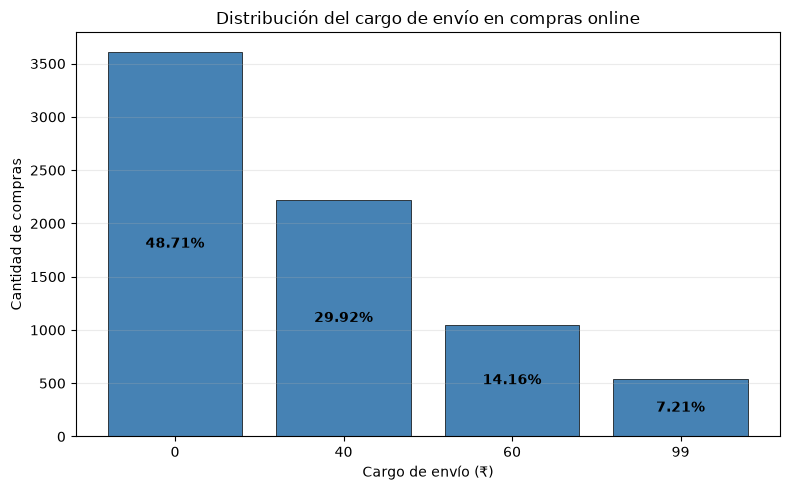

In [36]:
# Porcentaje de compras online para cada cargo de envío
porcentaje_envio = (
    distribucion_envio / distribucion_envio.sum() * 100
).round(2)
# Gráfico de distribución del cargo de envío
plt.figure(figsize=(8, 5))
barras = plt.bar(
    distribucion_envio.index.astype(str),
    distribucion_envio.values,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)
plt.title("Distribución del cargo de envío en compras online")
plt.xlabel("Cargo de envío (₹)")
plt.ylabel("Cantidad de compras")
plt.grid(axis="y", alpha=0.25)
# Mostramos el porcentaje dentro de cada barra
for barra, cargo in zip(barras, distribucion_envio.index):
    porcentaje = porcentaje_envio[cargo]
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() / 2,
        f"{porcentaje:.2f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )
plt.tight_layout()
plt.show()

### Lectura del cargo de envío

El análisis se realizó únicamente sobre las 7.417 compras online, ya que en las compras presenciales el cargo de envío no aplica de la misma forma. Casi la mitad de las compras online, el 48,71%, no presenta cargo de envío. Entre las operaciones que sí tienen un cargo asociado, el valor más frecuente es ₹40, seguido por ₹60 y ₹99. La mediana del cargo de envío es ₹40, mientras que el promedio es ₹27,60 debido a la alta proporción de compras con envío sin cargo. Dentro del proyecto, esta variable se interpreta únicamente como el importe cobrado al cliente por el envío. No se utiliza como costo logístico, costo operativo ni margen, ya que el dataset no contiene información suficiente para realizar esas estimaciones. A nivel descriptivo, el cargo de envío presenta pocos valores posibles y una concentración importante en envío gratuito o de bajo importe. Su eventual utilización como variable predictiva deberá limitarse a situaciones en las que esta información esté disponible antes del momento de inferencia o pueda construirse a partir del historial previo del cliente, evitando fuga de información temporal.

## 11. Relaciones entre variables

Además de analizar cada variable por separado, en este bloque revisamos cómo se relacionan entre sí algunas de las características del dataset.

El objetivo es detectar asociaciones que puedan resultar útiles para la construcción de features y para la interpretación posterior de los modelos.

Las relaciones encontradas se consideran descriptivas y no implican causalidad.

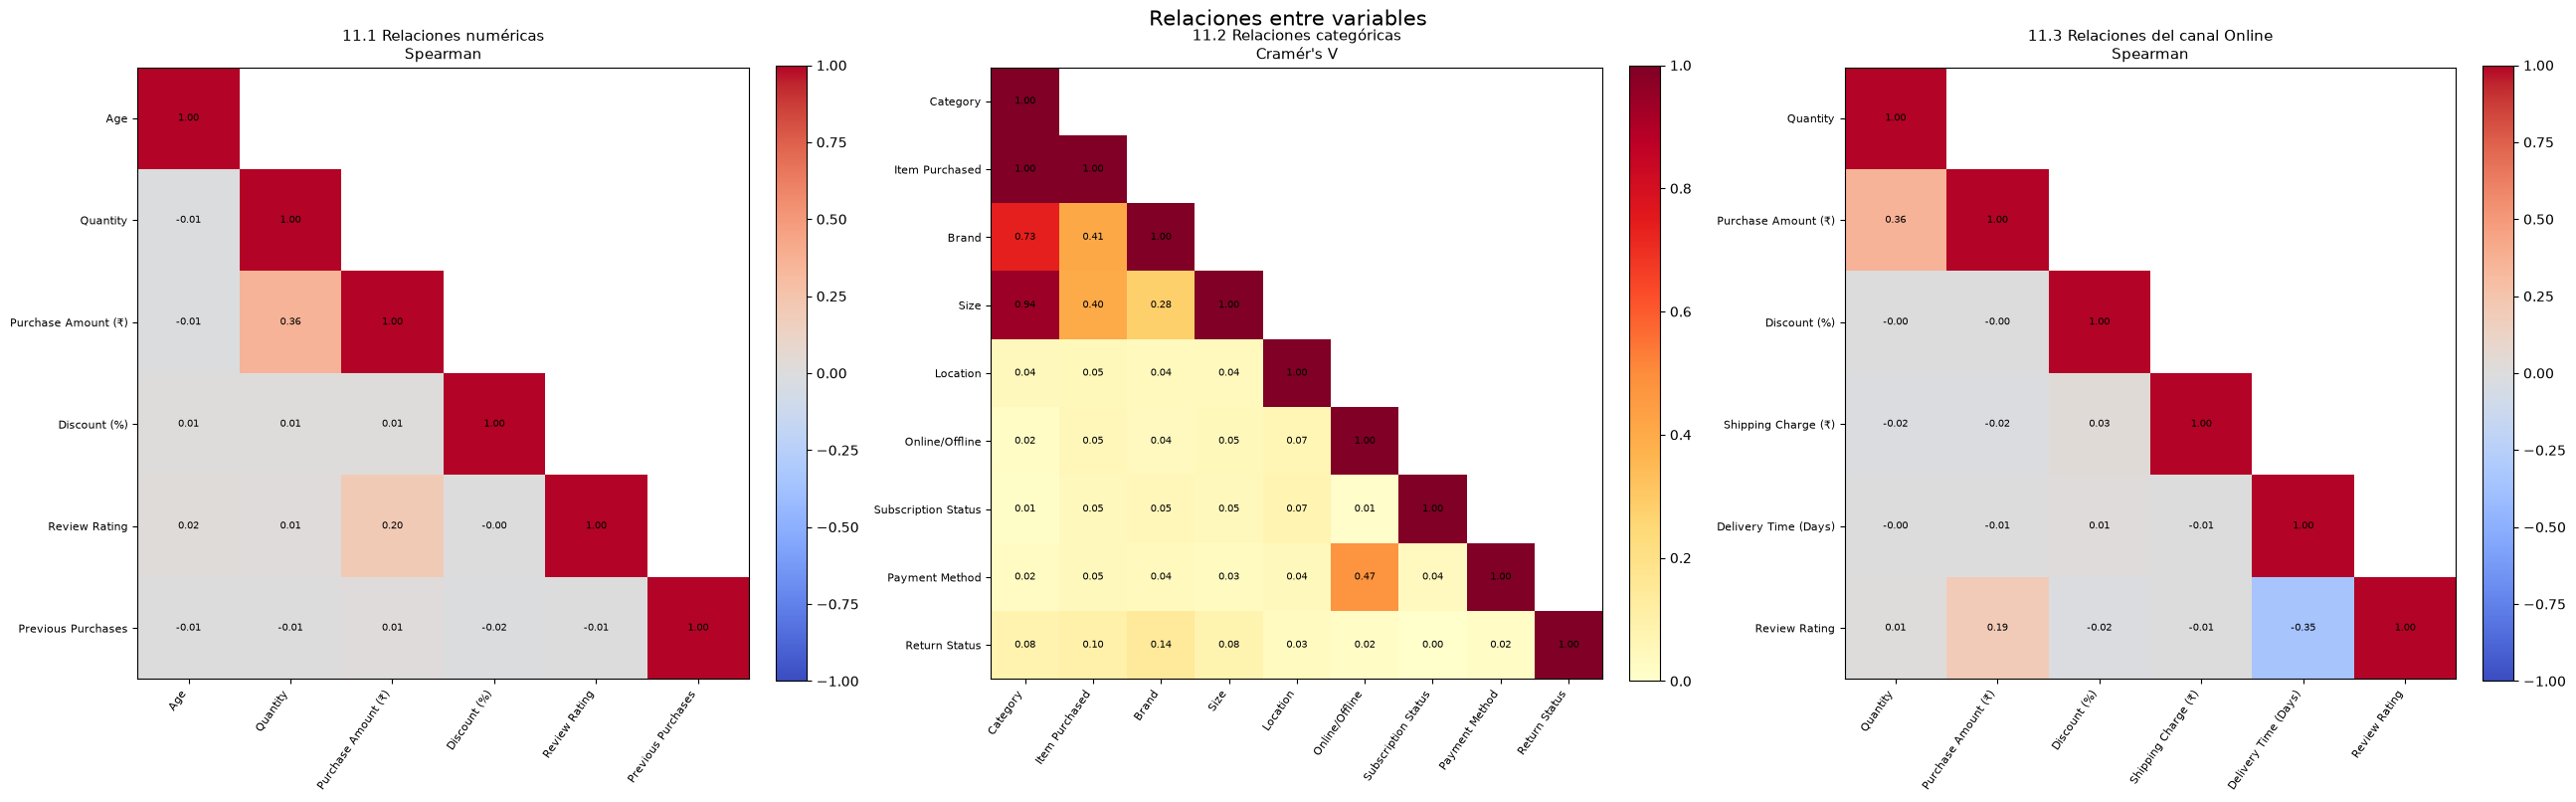

In [37]:
# =========================
# 11. Relaciones entre variables
# =========================


# ---------------------------------------------------------
# 11.1 Relaciones numéricas generales - Spearman
# ---------------------------------------------------------

variables_numericas = [
    "Age",
    "Quantity",
    "Purchase Amount (₹)",
    "Discount (%)",
    "Review Rating",
    "Previous Purchases"
]

correlacion_numerica = (
    df_eda[variables_numericas]
    .corr(method="spearman")
)


# ---------------------------------------------------------
# 11.2 Relaciones categóricas - Cramér's V
# ---------------------------------------------------------

variables_categoricas = [
    "Category",
    "Item Purchased",
    "Brand",
    "Size",
    "Location",
    "Online/Offline",
    "Subscription Status",
    "Payment Method",
    "Return Status"
]


# Calculamos Cramér's V para medir asociación entre dos variables categóricas
def cramers_v(serie_1, serie_2):

    tabla = pd.crosstab(serie_1, serie_2)

    chi2 = chi2_contingency(
        tabla,
        correction=False
    )[0]

    n = tabla.values.sum()

    filas, columnas = tabla.shape

    denominador = min(
        filas - 1,
        columnas - 1
    )

    if n == 0 or denominador == 0:
        return 0

    return np.sqrt(
        chi2 / (n * denominador)
    )


# Construimos la matriz de asociaciones categóricas
cramer_matrix = pd.DataFrame(
    index=variables_categoricas,
    columns=variables_categoricas,
    dtype=float
)

for variable_1 in variables_categoricas:

    for variable_2 in variables_categoricas:

        if variable_1 == variable_2:
            cramer_matrix.loc[variable_1, variable_2] = 1.0

        else:
            cramer_matrix.loc[variable_1, variable_2] = cramers_v(
                df_eda[variable_1],
                df_eda[variable_2]
            )


# ---------------------------------------------------------
# 11.3 Relaciones numéricas dentro del canal online
# ---------------------------------------------------------

df_online_relaciones = df_eda[
    df_eda["Online/Offline"] == "Online"
].copy()

variables_online = [
    "Quantity",
    "Purchase Amount (₹)",
    "Discount (%)",
    "Shipping Charge (₹)",
    "Delivery Time (Days)",
    "Review Rating"
]

correlacion_online = (
    df_online_relaciones[variables_online]
    .corr(method="spearman")
)


# ---------------------------------------------------------
# Función para dibujar únicamente diagonal + triángulo inferior
# ---------------------------------------------------------

def dibujar_matriz_triangular(
    ax,
    matriz,
    titulo,
    cmap,
    minimo,
    maximo
):

    valores = matriz.values

    # Ocultamos el triángulo superior para no repetir relaciones
    mascara_superior = np.triu(
        np.ones_like(valores, dtype=bool),
        k=1
    )

    valores_grafico = np.ma.masked_where(
        mascara_superior,
        valores
    )

    mapa_color = plt.get_cmap(cmap).copy()
    mapa_color.set_bad(alpha=0)

    imagen = ax.imshow(
        valores_grafico,
        cmap=mapa_color,
        vmin=minimo,
        vmax=maximo
    )

    ax.set_xticks(range(len(matriz.columns)))
    ax.set_yticks(range(len(matriz.index)))

    ax.set_xticklabels(
        matriz.columns,
        rotation=55,
        ha="right",
        fontsize=8
    )

    ax.set_yticklabels(
        matriz.index,
        fontsize=8
    )

    # Mostramos los valores solo una vez
    for i in range(len(matriz.index)):

        for j in range(len(matriz.columns)):

            if j <= i:

                ax.text(
                    j,
                    i,
                    f"{valores[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=7
                )

    ax.set_title(
        titulo,
        fontsize=11
    )

    return imagen


# =========================================================
# Los tres análisis en una sola línea
# =========================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(26, 8)
)


# 11.1
imagen_1 = dibujar_matriz_triangular(
    axes[0],
    correlacion_numerica,
    "11.1 Relaciones numéricas\nSpearman",
    "coolwarm",
    -1,
    1
)

fig.colorbar(
    imagen_1,
    ax=axes[0],
    fraction=0.046,
    pad=0.04
)


# 11.2
imagen_2 = dibujar_matriz_triangular(
    axes[1],
    cramer_matrix,
    "11.2 Relaciones categóricas\nCramér's V",
    "YlOrRd",
    0,
    1
)

fig.colorbar(
    imagen_2,
    ax=axes[1],
    fraction=0.046,
    pad=0.04
)


# 11.3
imagen_3 = dibujar_matriz_triangular(
    axes[2],
    correlacion_online,
    "11.3 Relaciones del canal Online\nSpearman",
    "coolwarm",
    -1,
    1
)

fig.colorbar(
    imagen_3,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)


fig.suptitle(
    "Relaciones entre variables",
    fontsize=15
)

plt.tight_layout()
plt.show()

### 11.1 Relaciones numéricas

Entre las variables numéricas no aparecen correlaciones fuertes. La relación más marcada se observa entre `Quantity` y `Purchase Amount (₹)`, con una correlación de Spearman de 0,36. Esto indica que las transacciones con mayor cantidad de productos tienden a presentar montos superiores, aunque la relación no es lo suficientemente alta como para considerar que ambas variables representan la misma información. También aparece una relación positiva débil entre `Purchase Amount (₹)` y `Review Rating`, con un valor de 0,20. El resto de las asociaciones se encuentra prácticamente alrededor de cero. En términos descriptivos, esto indica que las variables numéricas analizadas aportan información relativamente diferente entre sí y no se observa un problema evidente de correlaciones muy altas. Sin embargo, algunas variables como `Review Rating` corresponden a información conocida después de realizada la compra. Por lo tanto, estas relaciones resultan útiles para comprender el comportamiento histórico, pero su incorporación como features predictivas deberá evaluarse teniendo en cuenta el momento en que la información se encuentra disponible.

### 11.2 Relaciones categóricas

Las variables categóricas muestran asociaciones más claras que las variables numéricas. La relación entre `Category` e `Item Purchased` alcanza un Cramér's V de 1,00. Esto se debe a que cada producto pertenece a una categoría determinada, por lo que ambas variables contienen información directamente relacionada. También aparece una asociación muy alta entre `Category` y `Size` (0,94), algo consistente con lo observado anteriormente: las categorías utilizan escalas de talle diferentes. `Category` y `Brand` presentan una asociación de 0,73, mientras que `Item Purchased` mantiene asociaciones moderadas con `Brand` (0,41) y `Size` (0,40). Otra relación relevante aparece entre `Online/Offline` y `Payment Method`, con un valor de 0,47, lo que indica que la elección del medio de pago presenta diferencias según el canal de compra. El resto de las asociaciones es bajo. Estas relaciones deberán considerarse al momento de construir las features, especialmente para evitar incorporar información redundante entre variables que representan aspectos muy relacionados del producto y para asegurar que las variables utilizadas estén disponibles antes del momento de predicción.

### 11.3 Relaciones dentro del canal online

Al analizar únicamente las compras online se evita que los valores estructurales utilizados en las compras offline afecten las variables relacionadas con envío y entrega. La relación entre `Quantity` y `Purchase Amount (₹)` se mantiene en 0,36, prácticamente igual a la observada en el dataset completo. La asociación más importante dentro de las variables propias del canal online aparece entre `Delivery Time (Days)` y `Review Rating`, con una correlación negativa de -0,35. Esto indica que, dentro del histórico, los tiempos de entrega más largos tienden a estar asociados con calificaciones más bajas. También se mantiene una relación positiva débil entre `Purchase Amount (₹)` y `Review Rating`, con un valor de 0,19. En cambio, `Shipping Charge (₹)` presenta correlaciones cercanas a cero con el resto de las variables analizadas, por lo que no aparece una relación monotónica clara entre el cargo cobrado por envío y el comportamiento observado. Tanto `Delivery Time (Days)` como `Review Rating` contienen información que se conoce después de realizada la compra. Por este motivo, estas asociaciones se interpretan principalmente de forma descriptiva y no habilitan por sí solas su utilización directa como features para predecir esa misma transacción. Cualquier uso predictivo deberá construirse a partir de información histórica disponible antes del momento de inferencia.

## 12. Conclusiones generales del EDA

El análisis permitió comprender la estructura del histórico de compras, caracterizar el comportamiento de clientes y productos e identificar qué variables pueden aportar información útil para las siguientes etapas del proyecto.

### Hallazgos principales

- El dataset contiene 10.000 transacciones correspondientes a 3.291 clientes. La mayoría de los clientes aparece más de una vez en el histórico, aunque esto no implica necesariamente una recompra dentro de una ventana temporal determinada.
- El volumen de compras se mantiene relativamente estable entre 2023 y 2024. No aparece una tendencia sostenida de crecimiento o caída y, con solamente dos años disponibles, no existe evidencia suficiente para afirmar que haya una estacionalidad fuerte.
- El canal online concentra el 74,17% de las transacciones. Sin embargo, el monto y la cantidad de productos por compra presentan valores similares entre los canales Online y Offline.
- Las compras se encuentran distribuidas entre las distintas ubicaciones sin que una ciudad domine claramente el histórico. Existen diferencias descriptivas en la proporción de compras Online y Offline entre ciudades, aunque estas diferencias no permiten concluir por sí solas que exista una asociación fuerte entre ubicación y canal.
- `Clothing` representa el 50,04% de las transacciones, aunque esa concentración disminuye al analizar los productos individualmente. El producto más frecuente, `Kurta`, representa el 8,70% del total.
- Los cinco productos más frecuentes concentran el 40,70% de las compras. Existe entonces una diferencia de popularidad entre productos, pero no un único artículo que domine el histórico.
- Las marcas presentan una concentración moderada. `Max` y `Puma` son las más frecuentes, aunque ninguna domina individualmente el dataset.
- La variable `Size` depende fuertemente de la categoría. `Accessories`, `Clothing` y `Footwear` utilizan escalas distintas y por eso no resulta conveniente interpretar el talle de forma aislada.
- La edad de los clientes se distribuye de forma bastante pareja entre 18 y 64 años. Tampoco aparece una concentración fuerte por género.
- La mayoría de las transacciones corresponde a compras de una sola unidad. Los montos presentan una distribución asimétrica hacia valores altos, con un grupo reducido de operaciones de mayor importe que no se consideran automáticamente errores.
- El 17,51% de las compras registra una devolución y el 29,57% corresponde a clientes suscriptos.
- `UPI` es el medio de pago más utilizado y concentra el 42,79% de las transacciones.
- En las compras online, el 48,71% no presenta cargo de envío. Esta variable se interpreta únicamente como importe cobrado al cliente y no como costo logístico.

### Relaciones relevantes para el modelado

Las variables numéricas presentan, en general, correlaciones bajas. La relación más marcada aparece entre `Quantity` y `Purchase Amount (₹)`, con una correlación de Spearman de 0,36. Entre las variables categóricas aparecen asociaciones más importantes. `Category` e `Item Purchased` presentan una asociación de 1,00 y `Category` con `Size` alcanza 0,94, lo que confirma que parte de estas variables contiene información fuertemente relacionada. También aparece una asociación de 0,47 entre `Online/Offline` y `Payment Method`, indicando diferencias en la forma de pago observada según el canal. Dentro del canal online, `Delivery Time (Days)` y `Review Rating` presentan una correlación negativa de -0,35. Los tiempos de entrega más largos tienden a estar asociados con calificaciones menores dentro del histórico, aunque esta relación es descriptiva y no implica causalidad. Algunas de estas variables, como `Review Rating`, `Delivery Time (Days)`, `Return Status` o determinadas características de la transacción actual, se conocen después de realizada la compra. Por este motivo, su presencia en el análisis descriptivo no implica que puedan utilizarse directamente como features predictivas. La construcción del modelo deberá utilizar únicamente información disponible antes del momento de inferencia o variables construidas a partir del historial previo del cliente, evitando fuga de información temporal.

### Implicancias para ReActiva

El EDA muestra que existen distintas fuentes de información que pueden aportar contexto al recomendador: historial del cliente, producto, categoría, marca, ubicación, canal y variables temporales. El historial de transacciones permite construir características relacionadas con frecuencia, recencia y preferencias previas sin depender de variables declaradas de frecuencia de compra. Las fechas también permitirán identificar posteriormente a los clientes que superen el umbral de inactividad definido para ReActiva y separar correctamente la información histórica disponible de los eventos futuros. La popularidad de los productos deberá utilizarse como baseline para evaluar si el modelo principal realmente aporta personalización adicional. Las asociaciones detectadas entre algunas variables también deberán tenerse en cuenta durante la construcción de features para evitar redundancia y seleccionar únicamente información disponible en el momento de generar la recomendación.

### Limitaciones y supuestos

El histórico disponible cubre únicamente dos años de actividad. No contiene información de navegación, búsquedas, clics, productos agregados al carrito, margen, costo real de productos ni costos logísticos. Las relaciones observadas durante el EDA son descriptivas. Una asociación entre variables no implica que una sea causa de la otra. Del mismo modo, una variable presente en el histórico no necesariamente se encuentra disponible en el momento en que el sistema debe generar una recomendación. Los valores extremos identificados en variables como `Purchase Amount (₹)` fueron registrados pero no eliminados automáticamente, ya que no existe evidencia suficiente para considerarlos errores. Las compras offline utilizan valores estructurales para algunas variables vinculadas a envío y entrega. Por este motivo, esas relaciones fueron analizadas por separado cuando correspondía. Este EDA deja una base descriptiva para avanzar con la construcción de features, la definición del baseline y la comparación posterior con el modelo principal de recomendación, manteniendo separación temporal entre información histórica y eventos posteriores a la predicción.